In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import KFold
import lightgbm as lgbm
from sklearn.metrics import mean_squared_error

# NOTE: "%matplotlib inline" is a Jupyter magic; it errors in plain .py runs.
# Keeping plots functional without the magic.
plt.rcParams["figure.dpi"] = 120



In [2]:
train = pd.read_csv("../input/petfinder-pawpularity-score/train.csv")
test = pd.read_csv("../input/petfinder-pawpularity-score/test.csv")



In [3]:
train.head()



,Id,Subject Focus,Eyes,Face,Near,Action,Accessory,Group,Collage,Human,Occlusion,Info,Blur,Pawpularity
0,1a8795e64a294ed0c95132e18ee198e1,0,1,1,1,0,0,0,0,0,0,0,0,55
1,08ce774252e822838bf598aa10518a11,0,1,1,1,0,0,0,0,0,0,0,0,100
2,a71c677d87606a56160b70c5f6fa4526,0,1,1,0,0,0,0,0,0,0,0,0,27
3,11d5914ad80403375c8e0ccd959fc08e,0,1,1,1,0,0,0,0,0,0,0,0,51
4,c04034bbfe0a0d89729541c2271a674e,0,1,1,1,0,0,0,0,0,0,0,0,48


In [4]:
# BUGFIX: train.corr() fails because "Id" is string; restrict to numeric columns.
train_corr = train.select_dtypes(include=[np.number]).corr()
train_corr



,Subject Focus,Eyes,Face,Near,Action,Accessory,Group,Collage,Human,Occlusion,Info,Blur,Pawpularity
Subject Focus,1.000000,0.079214,0.040622,0.057534,0.004414,0.029099,-0.050071,-0.038301,-0.074608,-0.076355,-0.039947,-0.046172,-0.012742
Eyes,0.079214,1.000000,0.584935,0.130222,-0.019711,0.051978,-0.084850,0.069939,0.037358,0.020617,0.040636,-0.508955,-0.016055
Face,0.040622,0.584935,1.000000,0.139080,-0.010138,0.034800,-0.106588,0.053745,0.025983,0.010077,0.024962,-0.062600,0.002306
Near,0.057534,0.130222,0.139080,1.000000,-0.019203,0.031132,-0.319996,-0.260031,0.064987,-0.006104,-0.143234,-0.011080,0.000390
Action,0.004414,-0.019711,-0.010138,-0.019203,1.000000,0.027867,-0.007605,-0.001734,-0.010506,-0.015076,-0.015890,0.017110,-0.005092
Accessory,0.029099,0.051978,0.034800,0.031132,0.027867,1.000000,-0.056962,0.067880,-0.038230,-0.032814,0.074471,-0.032394,0.010911
Group,-0.050071,-0.084850,-0.106588,-0.319996,-0.007605,-0.056962,1.000000,0.133201,-0.104275,0.003098,0.064354,0.005877,0.020392
Collage,-0.038301,0.069939,0.053745,-0.260031,-0.001734,0.067880,0.133201,1.000000,0.014389,0.055274,0.480268,-0.035000,0.004594
Human,-0.074608,0.037358,0.025983,0.064987,-0.010506,-0.038230,-0.104275,0.014389,1.000000,0.633096,0.021514,-0.018370,0.001640
Occlusion,-0.076355,0.020617,0.010077,-0.006104,-0.015076,-0.032814,0.003098,0.055274,0.633096,1.000000,0.120626,-0.007789,-0.000418


<Axes: >

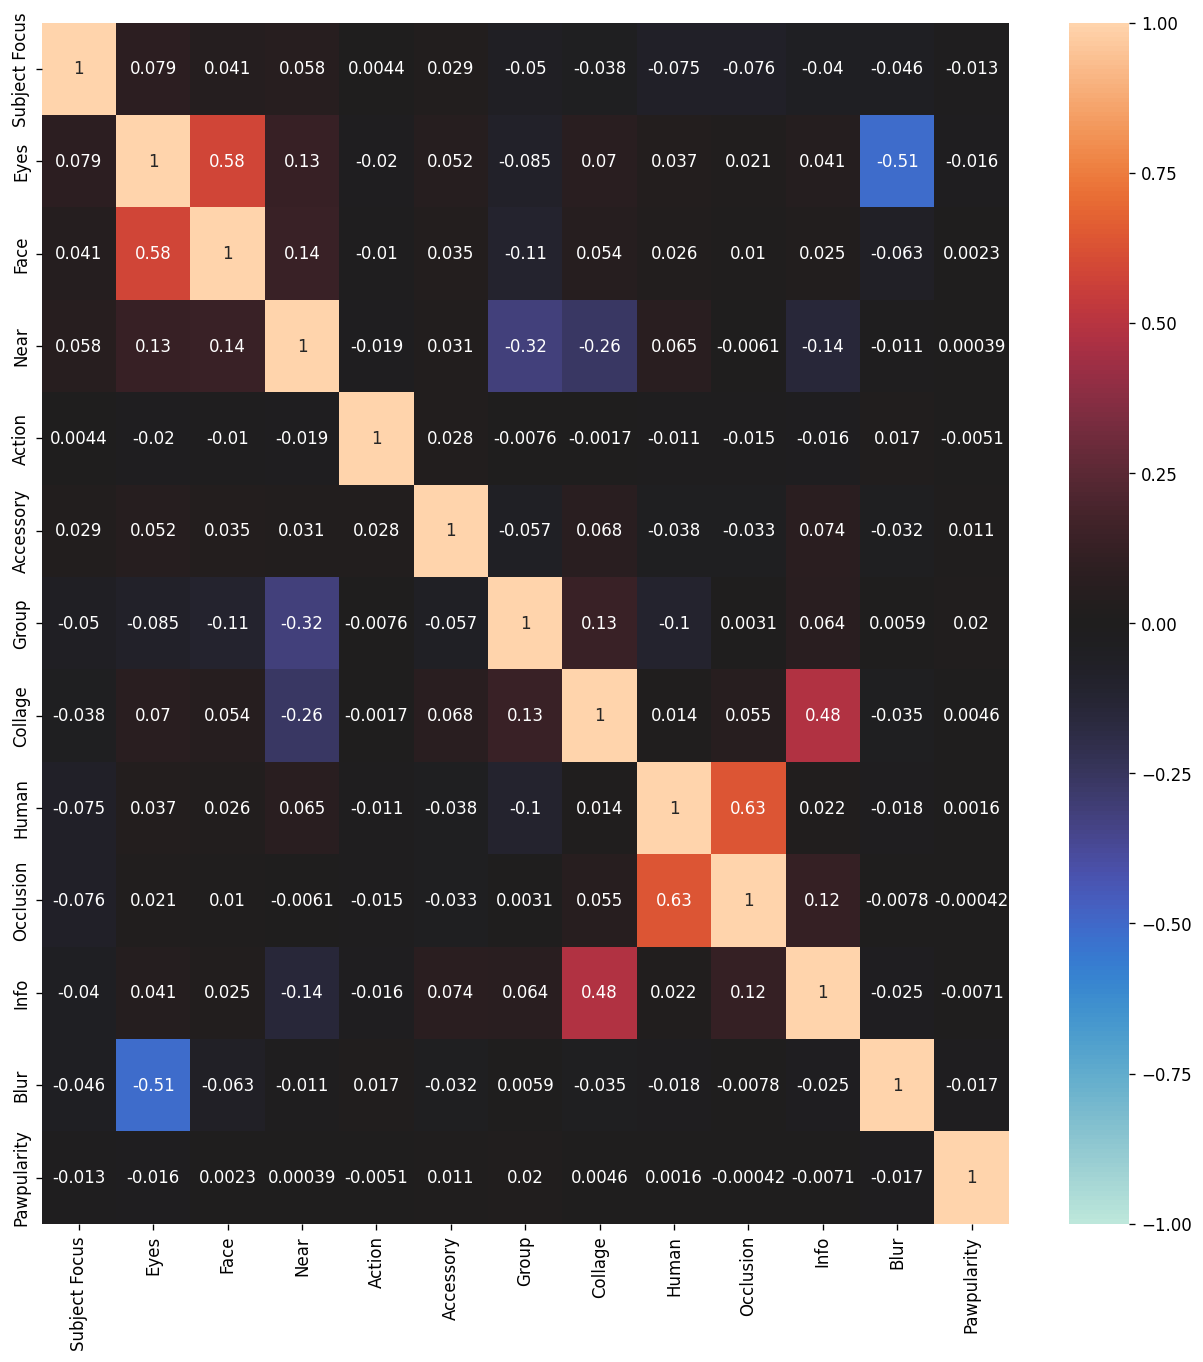

In [5]:
plt.figure(figsize=(13, 13))
sns.heatmap(train_corr, vmax=1, vmin=-1, center=0, annot=True)



<Axes: ylabel='Frequency'>

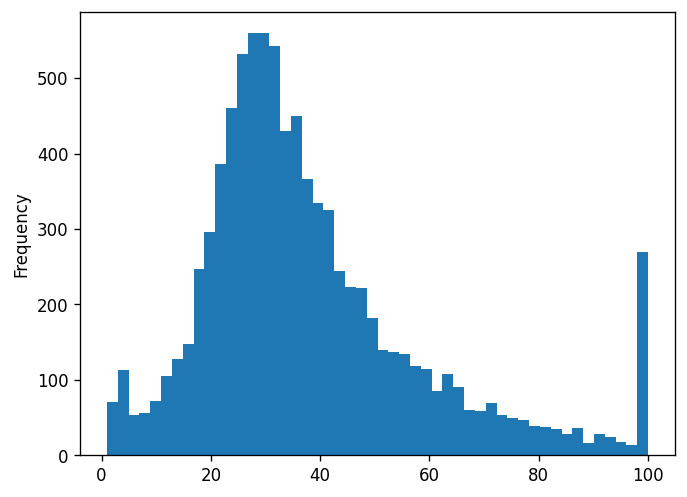

In [6]:
train["Pawpularity"].plot.hist(bins=50)



In [7]:
train["Id"] = train["Id"].astype("category")

X_train = train.drop(["Pawpularity"], axis=1)
Y_train = train["Pawpularity"]



In [8]:
kf = KFold(n_splits=3)
models = []
rmses = []
categories = ["Id"]

lgbm_params = {"random_seed": 1234}

for train_index, val_index in kf.split(X_train):
    XX_train = X_train.iloc[train_index]
    XX_valid = X_train.iloc[val_index]
    YY_train = Y_train.iloc[train_index]
    YY_valid = Y_train.iloc[val_index]

    lgbm_train = lgbm.Dataset(XX_train, YY_train, categorical_feature=categories)
    lgbm_eval = lgbm.Dataset(
        XX_valid, YY_valid, categorical_feature=categories, reference=lgbm_train
    )

    # BUGFIX: LightGBM v4+ removed verbose_eval; use callbacks for logging instead.
    model_lgbm = lgbm.train(
        lgbm_params,
        lgbm_train,
        valid_sets=[lgbm_eval],
        num_boost_round=100,
        callbacks=[lgbm.log_evaluation(period=10)],
    )

    y_pred = model_lgbm.predict(XX_valid, num_iteration=model_lgbm.best_iteration)

    tmp_rmse = np.sqrt(mean_squared_error(YY_valid, y_pred))
    print(tmp_rmse)

    models.append(model_lgbm)
    rmses.append(tmp_rmse)



[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000261 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 27
[LightGBM] [Info] Number of data points in the train set: 5946, number of used features: 13
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 38.143121
[10]	valid_0's l2: 417.026
[20]	valid_0's l2: 418.181
[30]	valid_0's l2: 419.254
[40]	valid_0's l2: 420.25
[50]	valid_0's l2: 420.378
[60]	valid_0's l2: 420.642
[70]	valid_0's l2: 420.776
[80]	valid_0's l2: 421.171
[90]	valid_0's l2: 421.544
[100]	valid_0's l2: 421.66
20.534364454075817
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhe

In [9]:
sum(rmses) / len(rmses)



20.77441313846298

In [10]:
test.head()



,Id,Subject Focus,Eyes,Face,Near,Action,Accessory,Group,Collage,Human,Occlusion,Info,Blur
0,ee51b99832f1ba868f646df93d2b6b81,0,1,1,1,0,0,0,0,0,0,0,0
1,caddfb3f8bff9c4b95dbe022018eea21,0,0,1,1,0,1,1,0,0,0,0,0
2,582eeabd4a448a53ebb79995888a4b0b,0,1,1,0,0,0,0,0,0,0,0,0
3,afc1ad7f0c5eea880759d09e77f7deee,0,1,1,1,0,0,0,0,0,0,0,0
4,d5bdf3446e86ce4ec67ce7a00f1cccc2,0,1,1,0,0,0,0,1,0,1,1,0


In [11]:
test["Id"] = test["Id"].astype("category")



In [12]:
preds = []

for model in models:
    pred = model.predict(test, num_iteration=model.best_iteration)
    preds.append(pred)

preds_array = np.array(preds)
preds_mean = np.mean(preds_array, axis=0)

# BUGFIX: Competition requires Pawpularity between 1 and 100.
preds_mean = np.clip(preds_mean, 1, 100)



In [13]:
sub = pd.DataFrame()
sub["Id"] = test["Id"].astype(str)  # ensure Id is written as string, not category codes
sub["Pawpularity"] = preds_mean
sub.to_csv("submission.csv", index=False)
sub.head()

,Id,Pawpularity
0,ee51b99832f1ba868f646df93d2b6b81,37.939742
1,caddfb3f8bff9c4b95dbe022018eea21,44.888496
2,582eeabd4a448a53ebb79995888a4b0b,37.153436
3,afc1ad7f0c5eea880759d09e77f7deee,37.939742
4,d5bdf3446e86ce4ec67ce7a00f1cccc2,30.445259
